In [12]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng()

In [41]:
# Collision Estimator
def russian_roulette(weight, ws):
    rand_num = rng.uniform()
    if rand_num < weight/ws:
        return True # particle survives
    else:
        return False

def current_region(dist, regions):
    for i in range(len(regions)):
        if dist <= regions[i]:
            # print(f"I am in region {i}")
            return i
            break

def slab_estimator(D, Sig_a, nuSig_f, regions, N, nu=2.5, inactive_cycles=5, active_cycles=50, graph=False):
    Sig_s = 1/3/D
    Sig_f = nuSig_f/nu
    Sig_t = Sig_a + Sig_s

    # Sample the initial fission sites randomly
    fission_sites = rng.uniform(0, regions[-1], N)
    positions = fission_sites.copy()
    weights = np.ones(N)
    mus = rng.uniform(-1, 1, N)
    old_gen = np.sum(weights)

    k = np.zeros(inactive_cycles + active_cycles)
    kc = np.zeros(inactive_cycles + active_cycles)
    ka = np.zeros(inactive_cycles + active_cycles)
    kp = np.zeros(inactive_cycles + active_cycles)
    Shannon_entropy = np.zeros(inactive_cycles+active_cycles)

    flux_c = np.zeros(int(regions[-1])) # array of Δr=1 elements
    flux_a = np.zeros(int(regions[-1]))
    flux_p = np.zeros(int(regions[-1]))
    for cycle in range(inactive_cycles + active_cycles):
        if cycle == 0:
            print("Inactive Cycles...")
        elif cycle == inactive_cycles:
            print("Active Cycles...")

        # make fission site and weights array for this cycle
        fission_sites = np.empty(1)
        # empty function makes me an array of a certain size with random bullshit numbers leftover in ram
        # in practice, the bs number is never used
        # the code deletes this initial number later
        fission_site_weights = np.empty(1)

        # Now we have different tallies
        #  these tallies track number of fission neutrons produced
        collision_tally = 0.0
        pathlength_tally = 0.0
        absorption_tally = 0.0
        
        
        for neutron in range(weights.size):
            position = positions[neutron]
            region = current_region(position, regions)
            weight = weights[neutron]
            mu = mus[neutron]
            alive = True
            while alive:

                # get distance to collision using Sig_s + Sig_t

                s = -np.log(1-rng.random()) / Sig_t[region]
                # randomly sampled distance using FFMC

                # move the particle
                position += s*mu

                # add to pathlength tally
                current_grid = int(position) # with Δr=1, current grid can be represented as the floor of the current position
                
                pathlength_tally += weight * nuSig_f[region] * s
                if position > regions[-1] or position < 0:
                    # exited slab
                    alive = False
                else: # a collision happened and we will tally it
                    flux_p[current_grid] += weight*s*np.abs(mu)/np.sum(weights) # so we don't add to nonexistent elements i=-1 or i=51
                    
                    # redefine current region to account for position change
                    region = current_region(position, regions)
                    # print(region)
                    collision_tally += weight * nuSig_f[region]/Sig_t[region]
                    flux_c[current_grid] += weight/Sig_t[region]/np.sum(weights)
                    
                    if rng.random() < Sig_s[region]/Sig_t[region]:
                        # scatter, pick new mu
                        mu = rng.uniform(-1, 1)
                    else:
                        alive = False # absorbed, kill particle
                        # add to absorption tally
                        absorption_tally += weight * nuSig_f[region]/Sig_a[region]
                        flux_a[current_grid] += weight/Sig_a[region]/np.sum(weights)
                        
                        # sample fission
                        if rng.random() <= Sig_f[region]/Sig_a[region]:
                            fission_sites = np.append(fission_sites, position)
                            fission_site_weights = np.append(fission_site_weights, weight)

        # Delete the initial site and weight
        fission_site_weights = np.delete(fission_site_weights, 0, axis=0)
        fission_sites = np.delete(fission_sites, 0, axis=0)

        if graph:
            plt.hist(fission_sites, bins=75)
            plt.xlabel("Location(cm)")
            plt.ylabel("Frequency")
            plt.title(f"Cycle {cycle}")
            plt.show()

        # Sample from the fission sites for the next generation
        num_per_site = int(np.ceil(N/fission_sites.size)) # normalize the fission source distribution (q^(n))
        positions = np.empty(1)
        weights = np.empty(1)
        mus = rng.uniform(-1, 1, num_per_site*fission_sites.size)
        for site in range(fission_sites.size):
            site_pos = fission_sites[site]
            site_weight = fission_site_weights[site]
            positions = np.append(positions, site_pos*np.ones((num_per_site, 1)))
            weights = np.append(weights, site_weight*nu/num_per_site*np.ones((num_per_site, 1)))

        # delete the initial site from position and weight vector
        positions = np.delete(positions, 0, axis=0)
        weights = np.delete(weights, 0, axis=0)

        # NOTE: k = neutrons produced / neutrons absorbed
        kc[cycle] = collision_tally / np.sum(weights)
        ka[cycle] = absorption_tally / np.sum(weights)
        kp[cycle] = pathlength_tally / np.sum(weights)

        # Shannon Entropy
        fission_distribution, edges = np.histogram(fission_sites, bins=7, range=(0,7))
        # print(fission_distribution)
        # print(fission_sites.size)
        Shannon_sum = 0
        for bin in range(fission_distribution.size):
            pj = fission_distribution[bin]/(fission_sites.size)
            if pj>0:
                # print(pj)
                Shannon_sum += pj*np.log2(pj)
        Shannon_entropy[cycle] = -Shannon_sum
        # print(Shannon_entropy)
        
        # store keff and update generation
        # new_gen = np.sum(weights)
        # k[cycle] = new_gen/old_gen
        # old_gen = new_gen

        # print("Collision Estimator")
        # print(f"\tCycle {cycle}, k={kc[cycle]:.5f}")
        # print("Absorption Estimator")
        # print(f"\tCycle {cycle}, k={ka[cycle]:.5f}")
        # print("Path-Length Estimator")
        # print(f"\tCycle {cycle}, k={kp[cycle]:.5f}")
        # print("*************************************")
    # print(flux_p)
    # print(flux_a)
    # print(flux_c)
    return kc, ka, kp, Shannon_entropy, flux_a, flux_p, flux_c

Inactive Cycles...
Active Cycles...


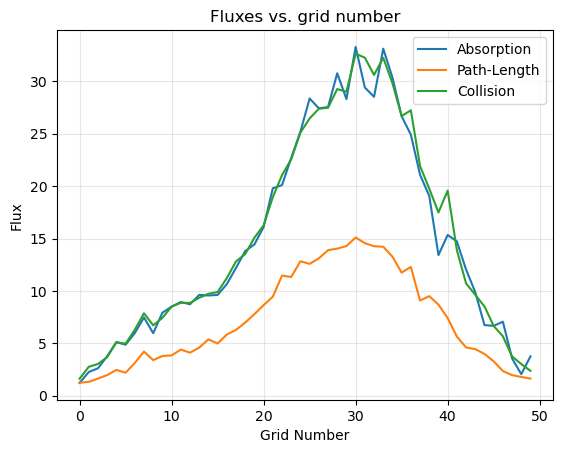

keff calculated from the three estimators: k = 1.01698


In [42]:
regions = np.array([10., 20., 30., 40., 50.])
D = np.array([1.1, 1.5, 1.1, 1.2, 2.])
Sig_a = np.array([0.070, 0.085, 0.070, 0.065, 0.020])
nuSig_f = np.array([0.095, 0.095, 0.095, 0.095, 0.])

kc, ka, kp, shannon, flux_a, flux_p, flux_c = slab_estimator(D, Sig_a, nuSig_f, regions, N=100, inactive_cycles=5, active_cycles=45, graph=False)

xs = np.arange(int(regions[-1]))
plt.plot(xs, flux_a, label="Absorption")
plt.plot(xs, flux_p, label="Path-Length")
plt.plot(xs, flux_c, label="Collision")
plt.title("Fluxes vs. grid number")
plt.legend()
plt.grid(visible=True, which="both", alpha=0.3)
plt.ylabel("Flux")
plt.xlabel("Grid Number")
plt.show()

k_col_mean = np.mean(kc)
k_abs_mean = np.mean(ka)
k_path_mean = np.mean(kp)

# Variances
S_cc = np.var(kc, ddof=1)
S_aa = np.var(ka, ddof=1)
S_pp = np.var(kp, ddof=1)
# Covariances
S_pc = np.cov(kp, kc, bias=False)[0, 1]
S_ac = np.cov(ka, kc, bias=False)[0, 1]
S_ap = np.cov(ka, kp, bias=False)[0, 1]

fc = S_aa*(S_pp - S_pc) - S_pp*S_ac + S_ap*(S_ac + S_pc - S_ap)
fa = S_pp*(S_cc - S_ac) - S_cc*S_ap + S_pc*(S_ap + S_ac - S_pc)
fp = S_cc*(S_aa - S_ap) - S_aa*S_pc + S_ac*(S_pc + S_ap - S_ac)

k = (fc*k_col_mean + fa*k_abs_mean + fp*k_path_mean) / (fc + fa + fp)
print(f"keff calculated from the three estimators: k = {k:.5f}")